# ============================================================
#          Apartment Price Prediction Project
# ============================================================

"""
Problem Statement
-----------------
Predict apartment prices using apartment features.

Target Variable
---------------
price

Machine Learning Type
---------------------
Regression

Workflow
--------
1- Data Understanding

2- Data Cleaning

3- Exploratory Data Analysis

4- Feature Engineering

5- Pipeline

6- Model Training

7- Hyperparameter Tuning

8- Model Evaluation

9- Feature Importance

10- Gradio Deployment
"""

In [1]:
# ===============================
# Data Handling
# ===============================

import numpy as np
import pandas as pd

# ===============================
# Visualization
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme()

# ===============================
# Ignore Warning
# ===============================

import warnings

warnings.filterwarnings("ignore")
# ===============================
# Machine Learning
# ===============================

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (

    StandardScaler,

    MinMaxScaler,

    RobustScaler,

    OneHotEncoder

)
# ===============================
# Regression Models
# ===============================

from sklearn.linear_model import LinearRegression

from sklearn.neighbors import KNeighborsRegressor

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (

    RandomForestRegressor,

    GradientBoostingRegressor

)

from sklearn.svm import SVR
# ===============================
# Metrics
# ===============================

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    mean_absolute_percentage_error,

    r2_score

)

In [34]:
df = pd.read_csv("/content/Apartments Prices Dataset.csv")

In [35]:
# Remove currency and commas
df['price'] = (
    df['price']
      .str.replace('EGP', '', regex=False)
      .str.replace(',', '', regex=False)
      .str.strip()
      .astype(float)
)

In [36]:
df.head()

,price,area_sqm,rooms,bathrooms,floor_level,year_built,seller_type,view,price_per_sqm,payment_method,finishing_type
0,2163000.0,120 m²,2 rooms,3 bathroom,3,2025,Developer,Main Street,"18,025 EGP/M²",Installments,Semi Finished
1,3250000.0,162 m²,3 rooms,2 bathroom,6,2024,Developer,Main Street,"20,062 EGP/M²",Cash or Installments,Semi Finished
2,2650000.0,122 m²,3 rooms,1 bathroom,4,2024,Developer,Main Street,"21,721 EGP/M²",Cash or Installments,Semi Finished
3,12720000.0,212 m²,4 rooms,3 bathroom,13,2027,Broker,Club,"60,000 EGP/M²",Cash or Installments,Extra Super Lux
4,5898000.0,135 m²,2 rooms,1 bathroom,6,2025,Developer,Lake,"43,689 EGP/M²",Cash or Installments,Super Lux


In [37]:
df.shape

(5578, 11)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5578 entries, 0 to 5577
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           5578 non-null   float64
 1   area_sqm        5578 non-null   object 
 2   rooms           5578 non-null   object 
 3   bathrooms       5578 non-null   object 
 4   floor_level     5578 non-null   object 
 5   year_built      5578 non-null   int64  
 6   seller_type     5578 non-null   object 
 7   view            5578 non-null   object 
 8   price_per_sqm   5578 non-null   object 
 9   payment_method  5578 non-null   object 
 10  finishing_type  5578 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 479.5+ KB


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,5578.0,6.052203e+06,4.528838e+06,500000.0,3400000.0,4900000.0,7500000.0,98380000.0
year_built,5578.0,2.022327e+03,8.431095e+00,1915.0,2023.0,2025.0,2026.0,2037.0


In [40]:
df.describe(include="object").T

,count,unique,top,freq
area_sqm,5578,251,140 m²,174
rooms,5578,11,3 rooms,3099
bathrooms,5578,11,1 bathroom,1969
floor_level,5578,22,1,1831
seller_type,5578,7,Broker,4872
view,5578,13,Main Street,1725
price_per_sqm,5578,2127,"50,000 EGP/M²",103
payment_method,5578,3,Cash,2571
finishing_type,5578,5,Super Lux,2264


In [41]:
quality = pd.DataFrame({

    "Column":df.columns,

    "Type":df.dtypes,

    "Missing":df.isnull().sum(),

    "Missing %":round(df.isnull().mean()*100,2),

    "Unique":df.nunique()

})

quality

,Column,Type,Missing,Missing %,Unique
price,price,float64,0,0.0,1321
area_sqm,area_sqm,object,0,0.0,251
rooms,rooms,object,0,0.0,11
bathrooms,bathrooms,object,0,0.0,11
floor_level,floor_level,object,0,0.0,22
year_built,year_built,int64,0,0.0,57
seller_type,seller_type,object,0,0.0,7
view,view,object,0,0.0,13
price_per_sqm,price_per_sqm,object,0,0.0,2127
payment_method,payment_method,object,0,0.0,3


In [42]:
df.isnull().sum()

,0
price,0
area_sqm,0
rooms,0
bathrooms,0
floor_level,0
year_built,0
seller_type,0
view,0
price_per_sqm,0
payment_method,0


In [43]:
print(

    "Duplicates :",

    df.duplicated().sum()

)

Duplicates : 1489


In [44]:
df.drop_duplicates(inplace=True)

df.reset_index(

    drop=True,

    inplace=True

)

In [45]:
df.columns

Index(['price', 'area_sqm', 'rooms', 'bathrooms', 'floor_level', 'year_built',
       'seller_type', 'view', 'price_per_sqm', 'payment_method',
       'finishing_type'],
      dtype='object')

In [46]:
numerical_features = df.select_dtypes(

    include=['int64','float64']

).columns.tolist()

categorical_features = df.select_dtypes(

    include='object'

).columns.tolist()

print("Numerical Features")

print(numerical_features)

print()

print("Categorical Features")

print(categorical_features)

Numerical Features
['price', 'year_built']

Categorical Features
['area_sqm', 'rooms', 'bathrooms', 'floor_level', 'seller_type', 'view', 'price_per_sqm', 'payment_method', 'finishing_type']


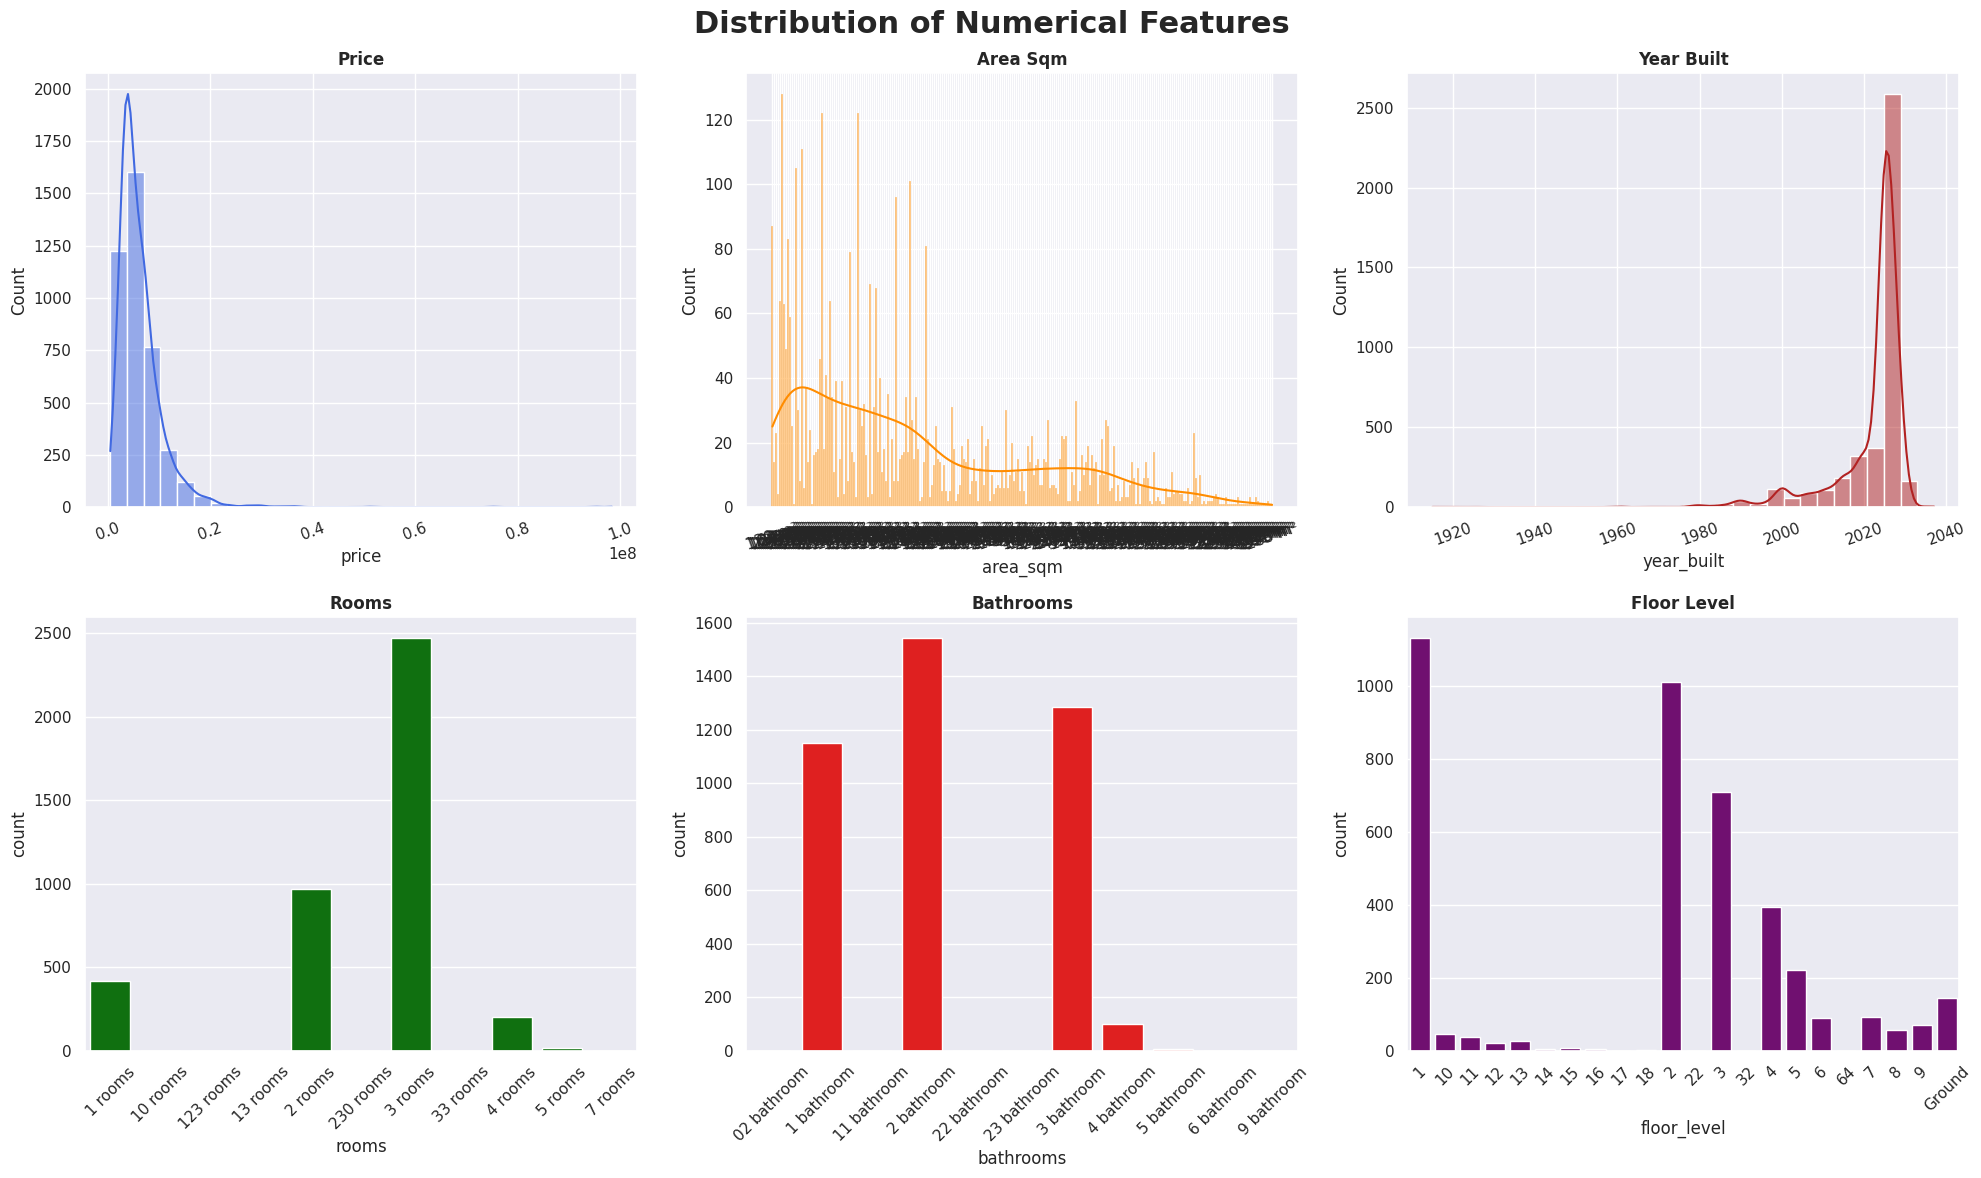

In [47]:
fig, ax = plt.subplots(2,3, figsize=(20,12))

# Continuous Features
continuous = [
    ('price','royalblue'),
    ('area_sqm','darkorange'),
    ('year_built','firebrick')
]

for i,(col,color) in enumerate(continuous):

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color=color,
        ax=ax.flat[i]
    )

    ax.flat[i].set_title(col.replace("_"," ").title(), fontweight="bold")
    ax.flat[i].tick_params(axis='x', rotation=20)


# Discrete Features
discrete = [
    ('rooms','green'),
    ('bathrooms','red'),
    ('floor_level','purple')
]

for j,(col,color) in enumerate(discrete, start=3):

    order = sorted(df[col].dropna().unique())

    sns.countplot(
        data=df,
        x=col,
        order=order,
        color=color,
        ax=ax.flat[j]
    )

    ax.flat[j].set_title(col.replace("_"," ").title(), fontweight="bold")

    # لو القيم كتير لف الأرقام
    ax.flat[j].tick_params(axis='x', rotation=45)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

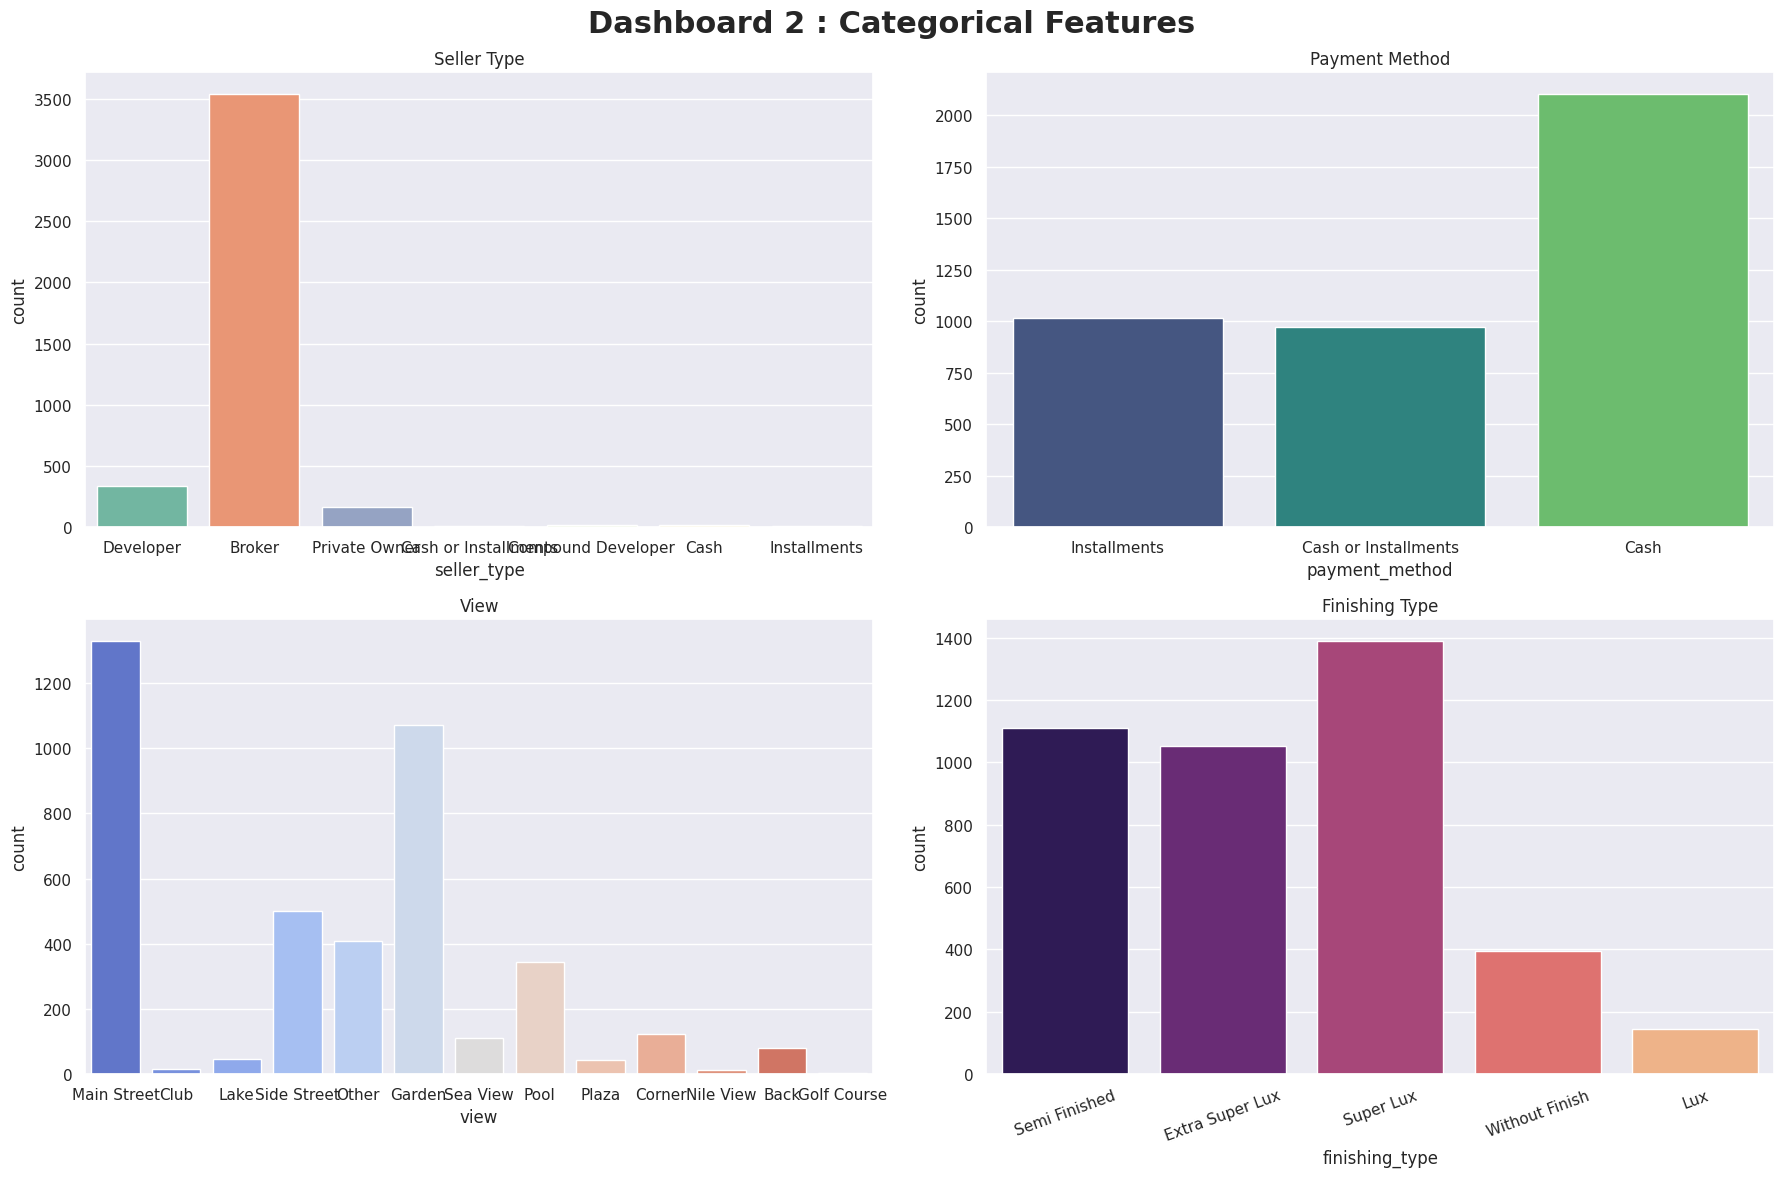

In [48]:
fig,ax=plt.subplots(2,2,figsize=(18,12))

sns.countplot(

    data=df,

    x="seller_type",

    palette="Set2",

    ax=ax[0,0]

)

ax[0,0].set_title("Seller Type")

sns.countplot(

    data=df,

    x="payment_method",

    palette="viridis",

    ax=ax[0,1]

)

ax[0,1].set_title("Payment Method")

sns.countplot(

    data=df,

    x="view",

    palette="coolwarm",

    ax=ax[1,0]

)

ax[1,0].set_title("View")

sns.countplot(

    data=df,

    x="finishing_type",

    palette="magma",

    ax=ax[1,1]

)

ax[1,1].tick_params(axis="x",rotation=20)

ax[1,1].set_title("Finishing Type")

plt.suptitle(

    "Dashboard 2 : Categorical Features",

    fontsize=22,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

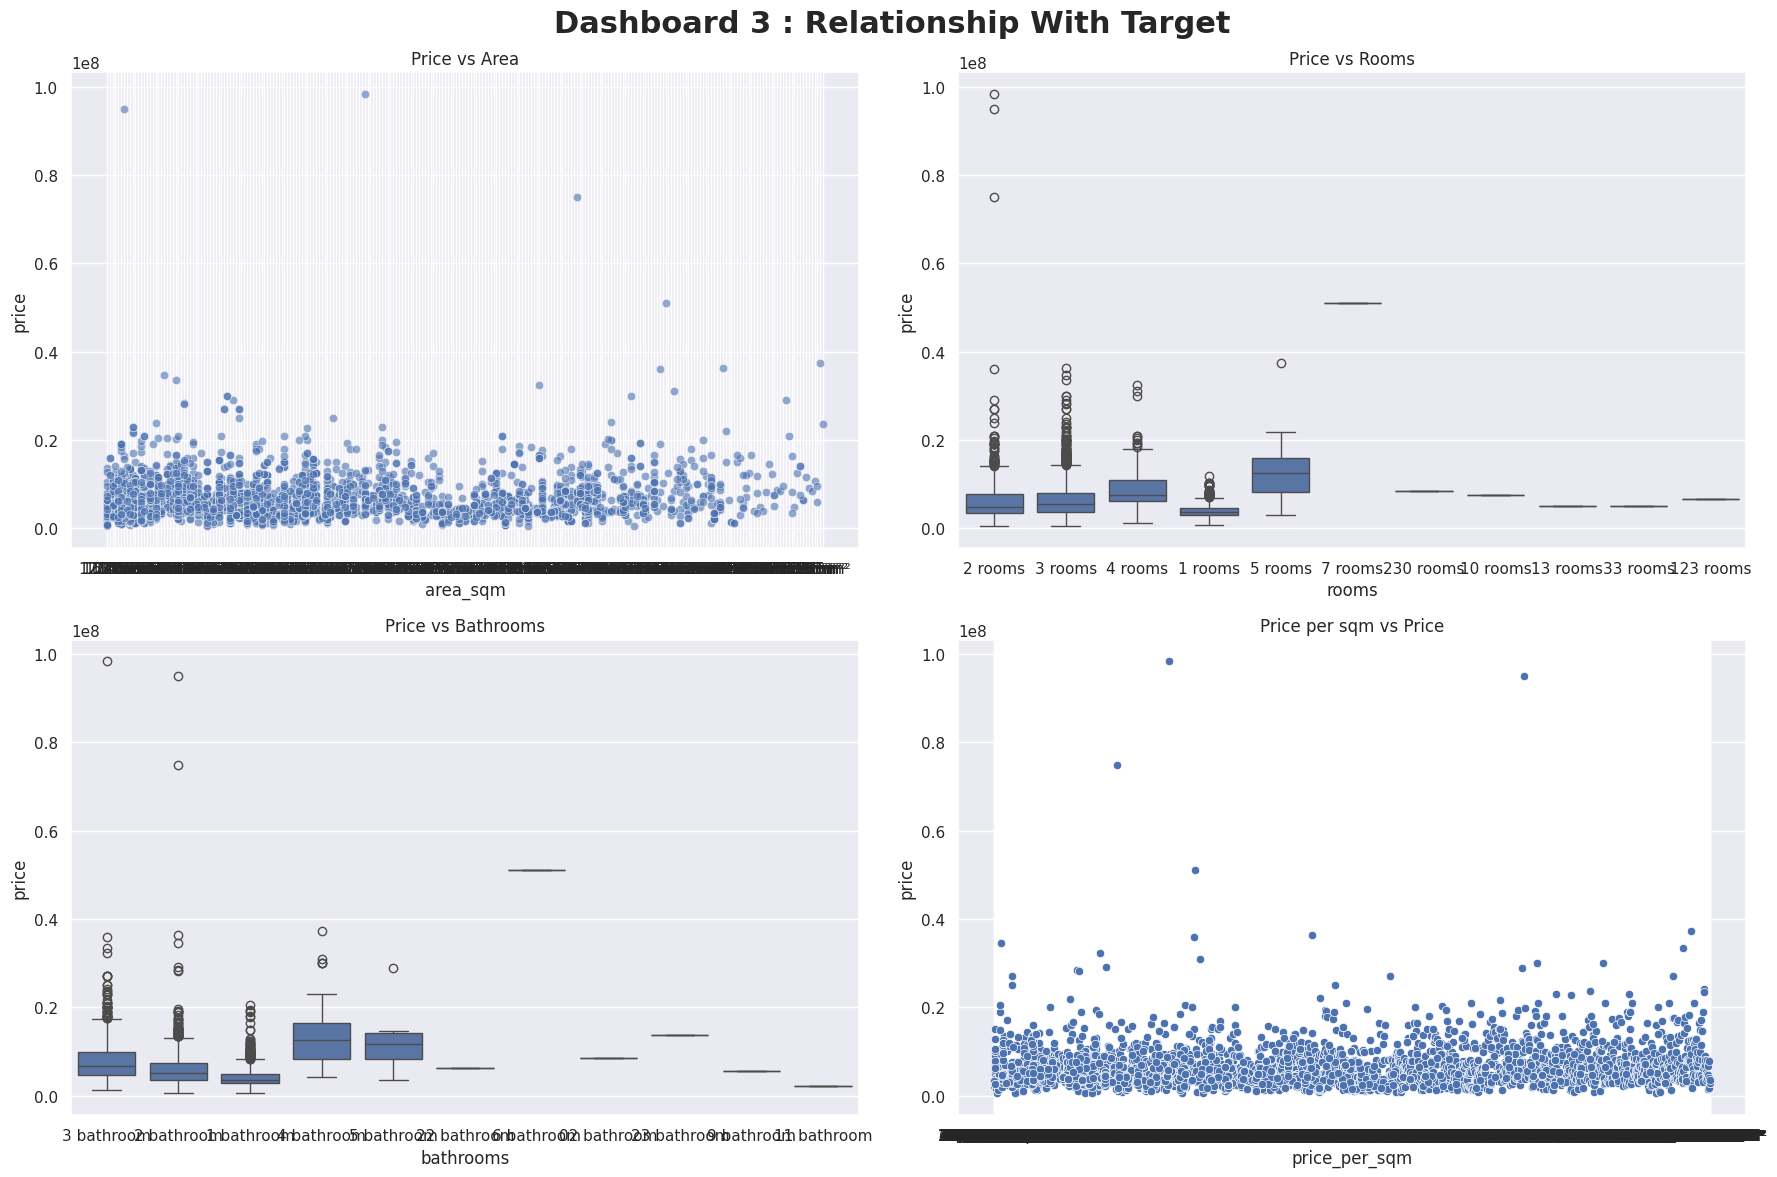

In [49]:
fig,ax=plt.subplots(2,2,figsize=(18,12))

sns.scatterplot(

    data=df,

    x="area_sqm",

    y="price",

    alpha=.6,

    ax=ax[0,0]

)

ax[0,0].set_title("Price vs Area")

sns.boxplot(

    data=df,

    x="rooms",

    y="price",

    ax=ax[0,1]

)

ax[0,1].set_title("Price vs Rooms")

sns.boxplot(

    data=df,

    x="bathrooms",

    y="price",

    ax=ax[1,0]

)

ax[1,0].set_title("Price vs Bathrooms")

sns.scatterplot(

    data=df,

    x="price_per_sqm",

    y="price",

    ax=ax[1,1]

)

ax[1,1].set_title("Price per sqm vs Price")

plt.suptitle(

    "Dashboard 3 : Relationship With Target",

    fontsize=22,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

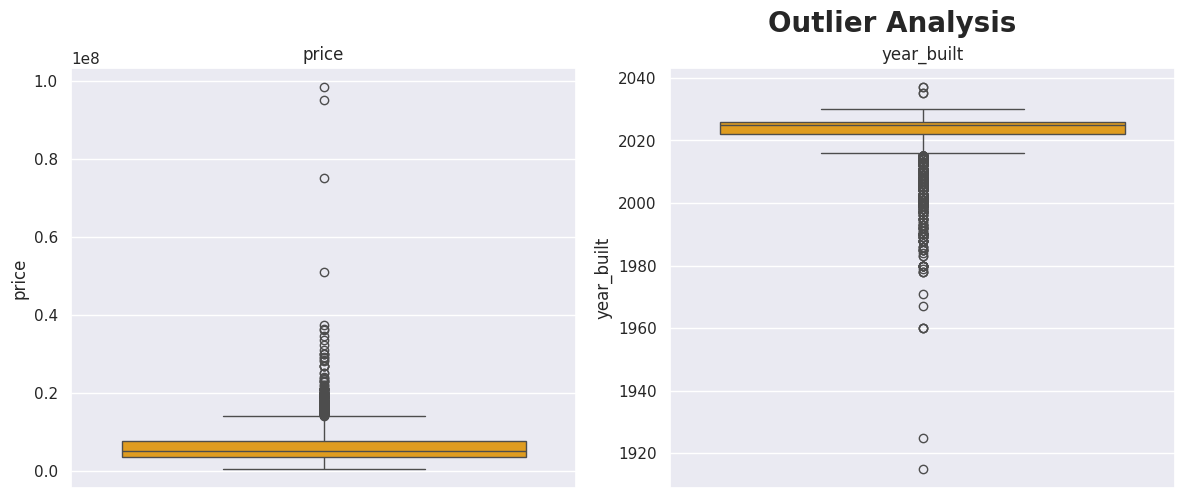

In [50]:
num=df.select_dtypes(include=np.number).columns

fig,ax=plt.subplots(3,3,figsize=(18,14))

ax=ax.flatten()

for i,col in enumerate(num):

    sns.boxplot(

        y=df[col],

        color="orange",

        ax=ax[i]

    )

    ax[i].set_title(col)

for j in range(i+1,len(ax)):

    fig.delaxes(ax[j])

plt.suptitle(

    "Outlier Analysis",

    fontsize=20,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

In [51]:
# Remove Data Leakage Feature
df.drop(columns='price_per_sqm', inplace=True)

# Features & Target
X = df.drop(columns='price')

y = df['price']

print(X.shape)
print(y.shape)

(4089, 9)
(4089,)


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Train :", X_train.shape)

print("Test :", X_test.shape)

Train : (3271, 9)
Test : (818, 9)


In [53]:
from sklearn.preprocessing import (

    StandardScaler,

    MinMaxScaler,

    RobustScaler

)

scalers = {

    "Standard": StandardScaler(),

    "MinMax": MinMaxScaler(),

    "Robust": RobustScaler()

}

In [54]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

In [55]:
numeric_features = X_train.select_dtypes(

    include=['int64','float64']

).columns.tolist()

categorical_features = X_train.select_dtypes(

    include='object'

).columns.tolist()

print("Numerical Features")

print(numeric_features)

print()

print("Categorical Features")

print(categorical_features)

Numerical Features
['year_built']

Categorical Features
['area_sqm', 'rooms', 'bathrooms', 'floor_level', 'seller_type', 'view', 'payment_method', 'finishing_type']


In [56]:
def build_preprocessor(scaler):

    numeric_pipeline = Pipeline([

        ("imputer",

         SimpleImputer(strategy="median")),

        ("scaler",

         scaler)

    ])

    categorical_pipeline = Pipeline([

        ("imputer",

         SimpleImputer(strategy="most_frequent")),

        ("encoder",

         OneHotEncoder(

             drop="first",

             handle_unknown="ignore"

         ))

    ])

    preprocessor = ColumnTransformer([

        (

            "num",

            numeric_pipeline,

            numeric_features

        ),

        (

            "cat",

            categorical_pipeline,

            categorical_features

        )

    ])

    return preprocessor

In [57]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

In [58]:
results_scaler = []

for name, scaler in scalers.items():

    preprocessor = build_preprocessor(scaler)

    pipe = Pipeline([

        ("preprocessor",

         preprocessor),

        ("model",

         LinearRegression())

    ])

    pipe.fit(

        X_train,

        y_train

    )

    pred = pipe.predict(

        X_test

    )

    results_scaler.append({

        "Scaler": name,

        "R2": r2_score(

            y_test,

            pred

        )

    })

In [59]:
results_scaler = pd.DataFrame(results_scaler)

results_scaler

,Scaler,R2
0,Standard,0.214675
1,MinMax,0.214667
2,Robust,0.214657


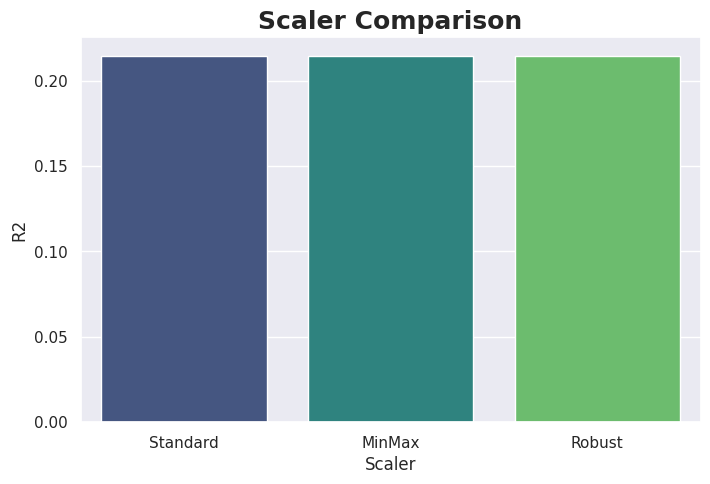

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results_scaler,

    x="Scaler",

    y="R2",

    palette="viridis"

)

plt.title(

    "Scaler Comparison",

    fontsize=18,

    fontweight="bold"

)

plt.show()

In [61]:
best_scaler = RobustScaler()

In [62]:
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

results = []
trained_models = {}

In [63]:
def train_model(model, model_name):

    pipe = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    #==============================
    # Train
    #==============================

    pipe.fit(X_train, y_train)

    #==============================
    # Prediction
    #==============================

    y_pred = pipe.predict(X_test)

    #==============================
    # Metrics
    #==============================

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    mape = mean_absolute_percentage_error(y_test, y_pred)

    n = len(y_test)

    p = X_train.shape[1]

    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

    results.append({

        "Model":model_name,

        "MAE":mae,

        "RMSE":rmse,

        "R2":r2,

        "Adj R2":adj_r2,

        "MAPE":mape

    })

    trained_models[model_name] = pipe

    #==============================
    # Print
    #==============================

    print("="*60)

    print(model_name)

    print("="*60)

    print(f"MAE  : {mae:,.2f}")

    print(f"RMSE : {rmse:,.2f}")

    print(f"R2   : {r2:.4f}")

    print(f"AdjR2: {adj_r2:.4f}")

    print(f"MAPE : {mape:.4f}")

    #==============================
    # Plots
    #==============================

    fig,ax=plt.subplots(1,3,figsize=(18,5))

    # Actual vs Predicted

    sns.scatterplot(

        x=y_test,

        y=y_pred,

        alpha=.6,

        ax=ax[0]

    )

    ax[0].plot(

        [y_test.min(),y_test.max()],

        [y_test.min(),y_test.max()],

        color="red"

    )

    ax[0].set_title("Actual vs Predicted")


    # Residual

    residual = y_test-y_pred

    sns.scatterplot(

        x=y_pred,

        y=residual,

        alpha=.6,

        ax=ax[1]

    )

    ax[1].axhline(

        0,

        color="red"

    )

    ax[1].set_title("Residual Plot")


    # Error Distribution

    sns.histplot(

        residual,

        kde=True,

        color="green",

        ax=ax[2]

    )

    ax[2].set_title("Residual Distribution")

    plt.tight_layout()

    plt.show()

    #==============================
    # Feature Importance
    #==============================

    estimator = pipe.named_steps["model"]

    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()

    if hasattr(estimator,"feature_importances_"):

        importance = pd.Series(

            estimator.feature_importances_,

            index=feature_names

        ).sort_values(ascending=False).head(15)

        plt.figure(figsize=(8,6))

        sns.barplot(

            x=importance.values,

            y=importance.index,

            palette="viridis"

        )

        plt.title(f"{model_name} Feature Importance")

        plt.show()

    elif hasattr(estimator,"coef_"):

        importance = pd.Series(

            np.abs(estimator.coef_),

            index=feature_names

        ).sort_values(ascending=False).head(15)

        plt.figure(figsize=(8,6))

        sns.barplot(

            x=importance.values,

            y=importance.index,

            palette="magma"

        )

        plt.title(f"{model_name} Coefficients")

        plt.show()

    return pipe

Linear Regression
MAE  : 2,293,342.18
RMSE : 4,576,096.69
R2   : 0.2147
AdjR2: 0.2059
MAPE : 0.4334


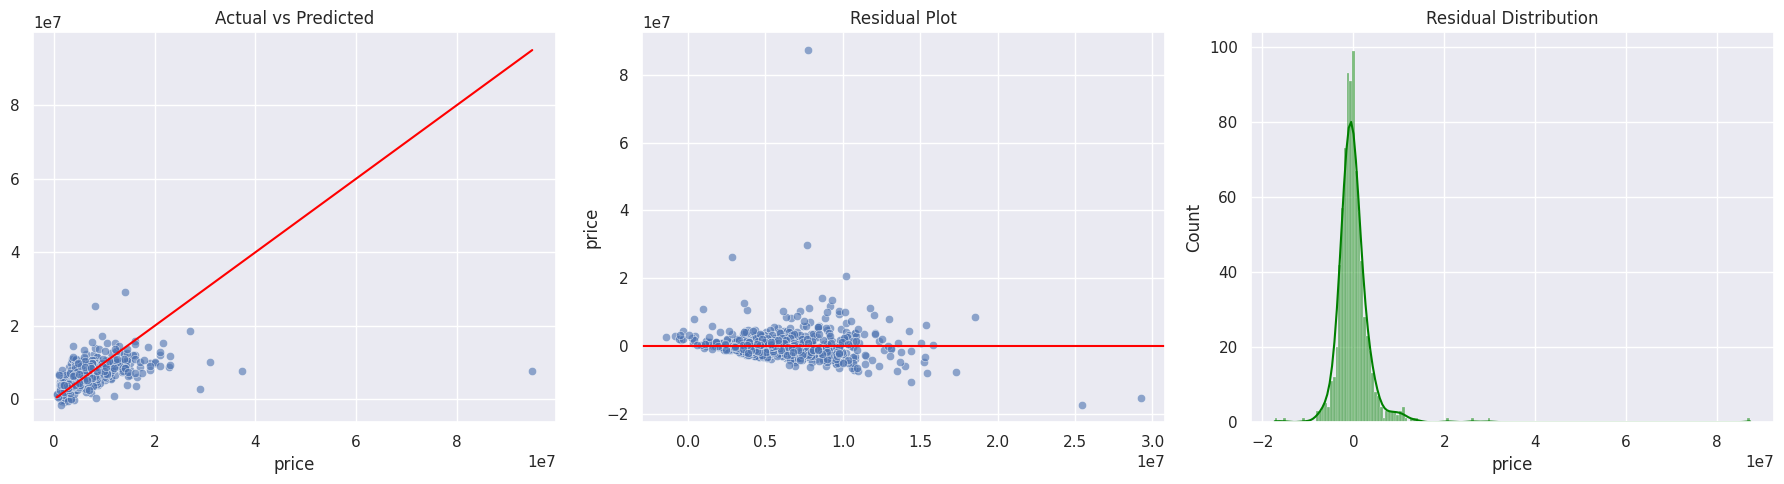

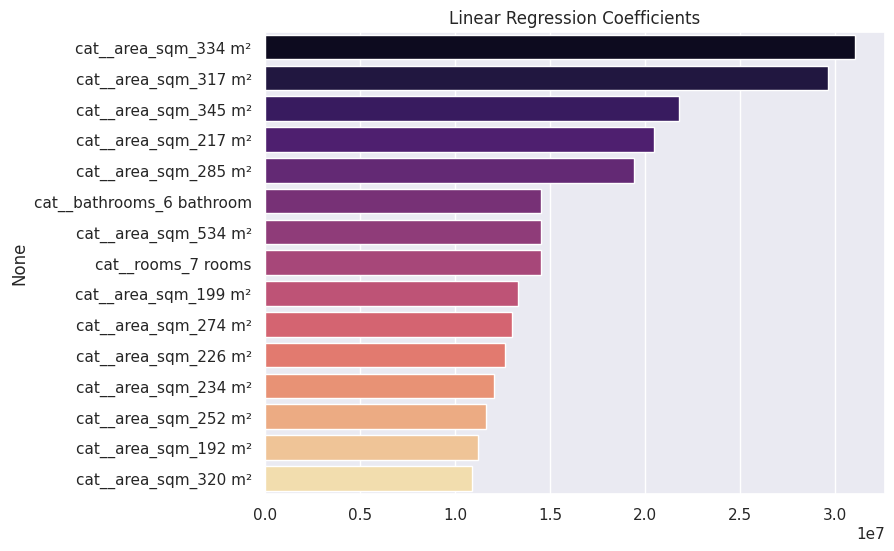

In [64]:
linear_model = train_model(

    LinearRegression(),

    "Linear Regression"

)

Ridge Regression
MAE  : 2,270,691.29
RMSE : 4,449,046.00
R2   : 0.2577
AdjR2: 0.2494
MAPE : 0.4513


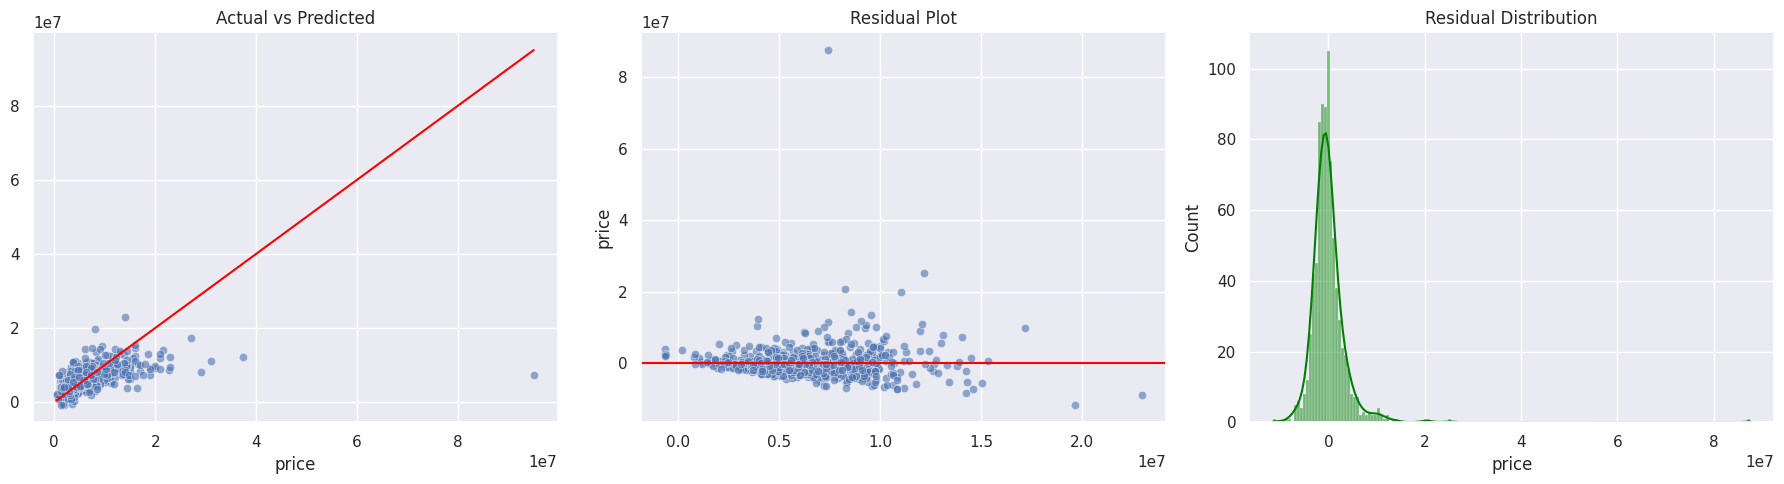

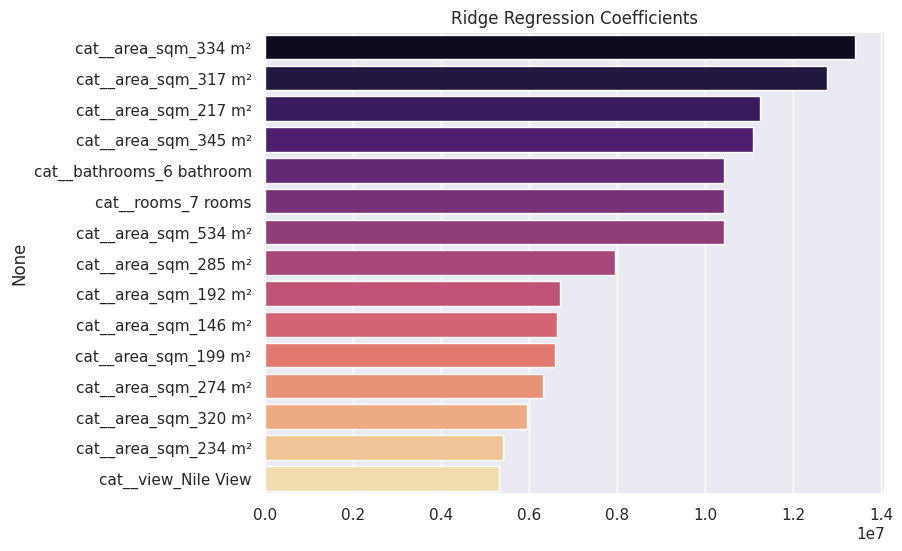

In [65]:
from sklearn.linear_model import Ridge

ridge_model = train_model(

    Ridge(random_state=42),

    "Ridge Regression"

)

Lasso Regression
MAE  : 2,293,162.48
RMSE : 4,575,790.27
R2   : 0.2148
AdjR2: 0.2060
MAPE : 0.4334


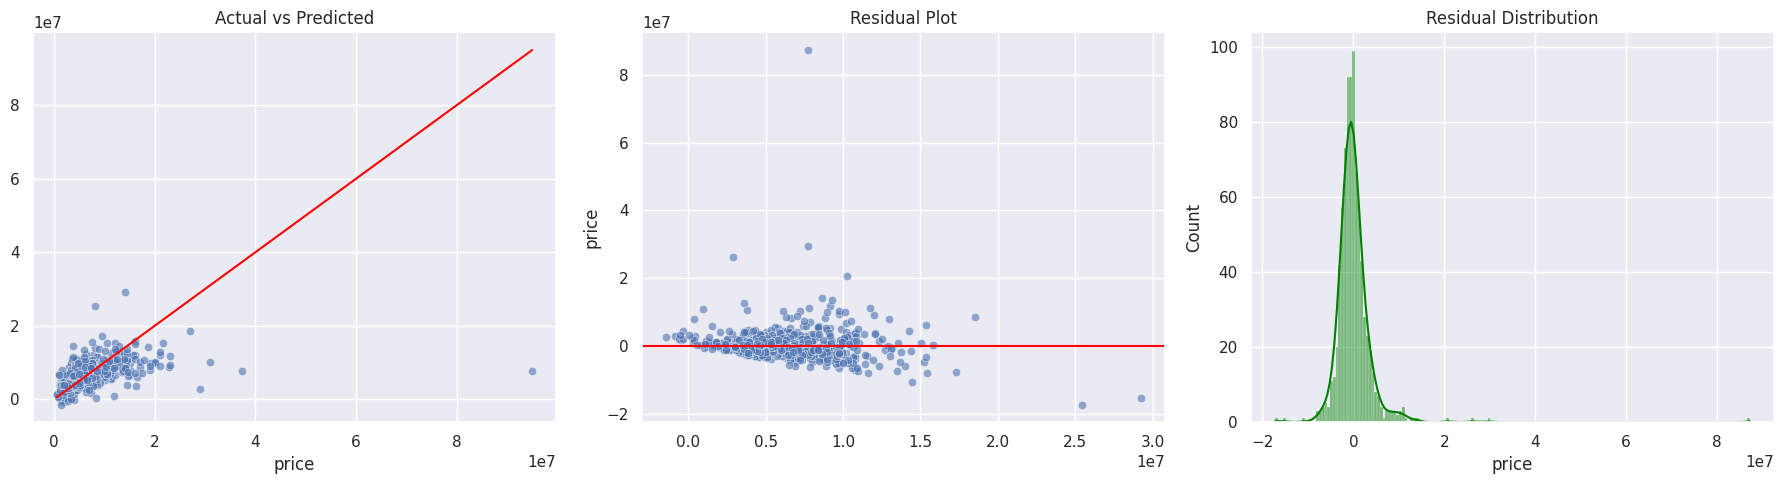

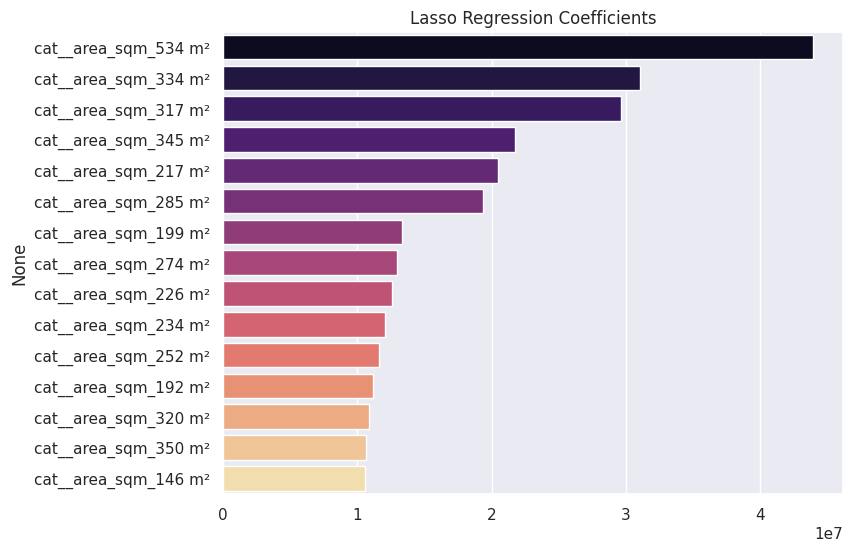

In [66]:
from sklearn.linear_model import Lasso

lasso_model = train_model(

    Lasso(random_state=42),

    "Lasso Regression"

)

Elastic Net
MAE  : 2,775,966.38
RMSE : 4,958,583.51
R2   : 0.0779
AdjR2: 0.0676
MAPE : 0.6163


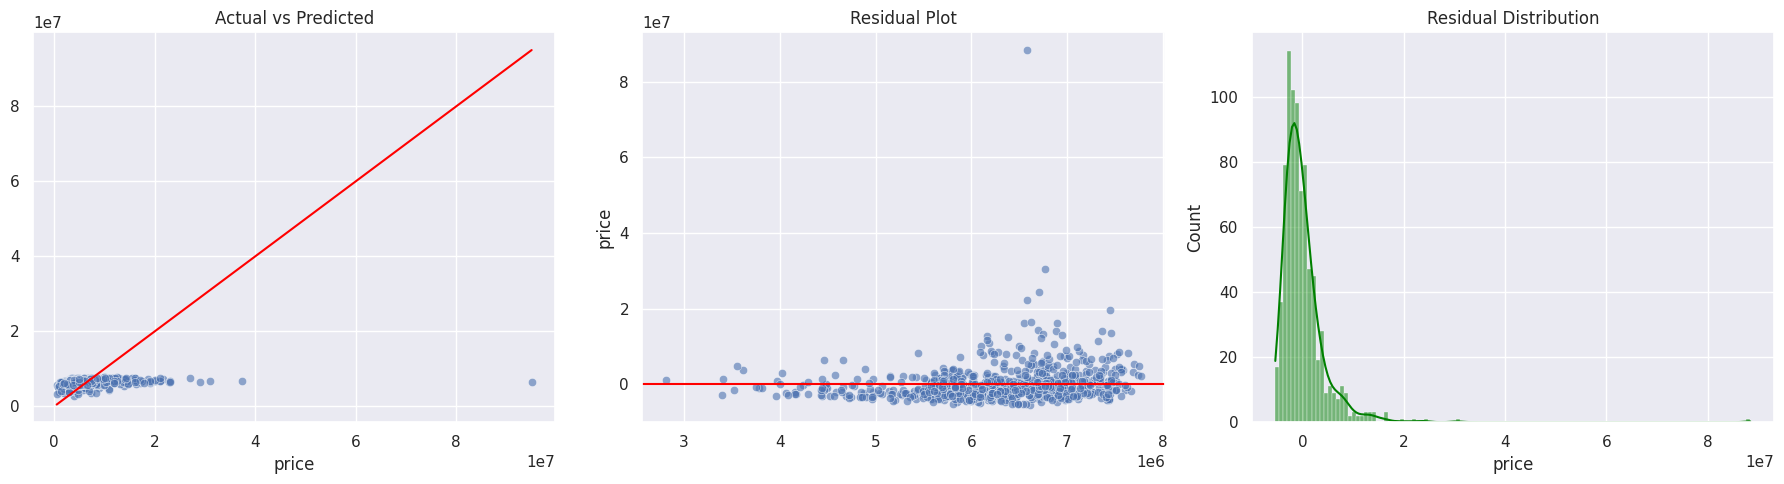

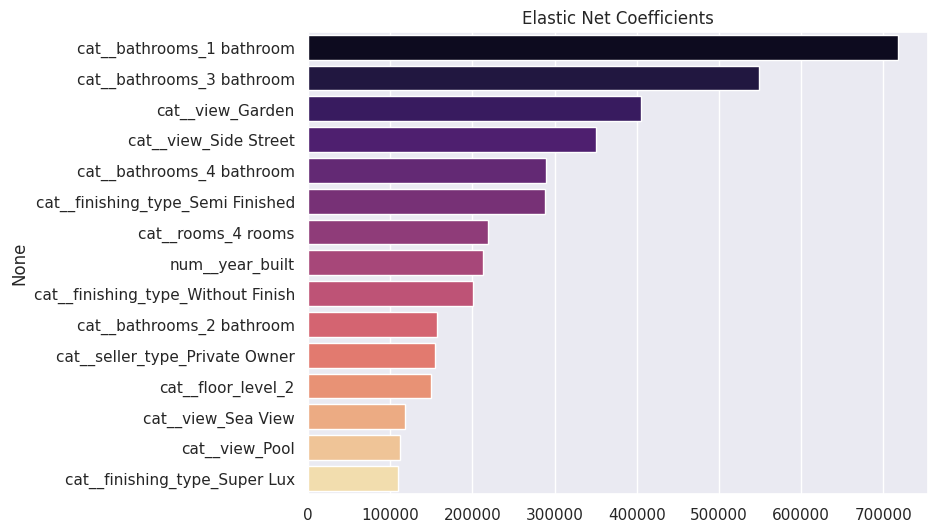

In [67]:
from sklearn.linear_model import ElasticNet

elastic_model = train_model(

    ElasticNet(random_state=42),

    "Elastic Net"

)

KNN Regressor
MAE  : 2,144,470.68
RMSE : 4,507,566.22
R2   : 0.2380
AdjR2: 0.2295
MAPE : 0.3944


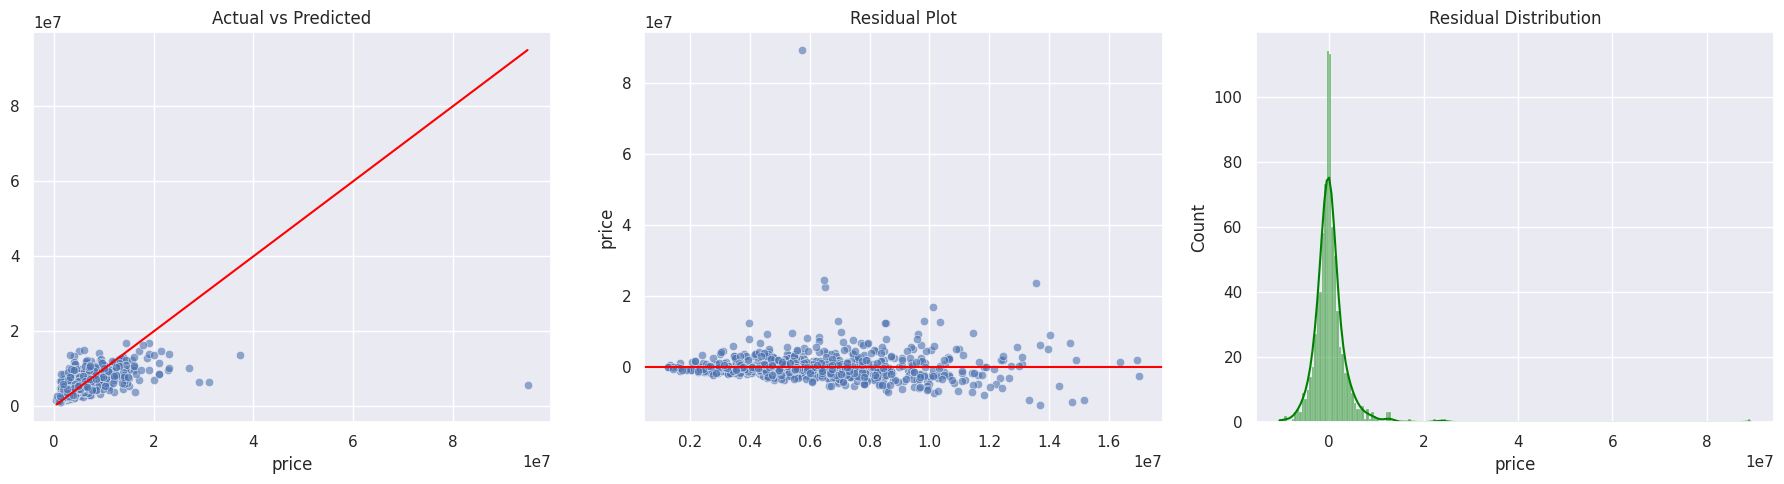

In [68]:
knn_model = train_model(

    KNeighborsRegressor(),

    "KNN Regressor"

)

Decision Tree
MAE  : 2,187,526.80
RMSE : 4,321,320.92
R2   : 0.2997
AdjR2: 0.2919
MAPE : 0.4321


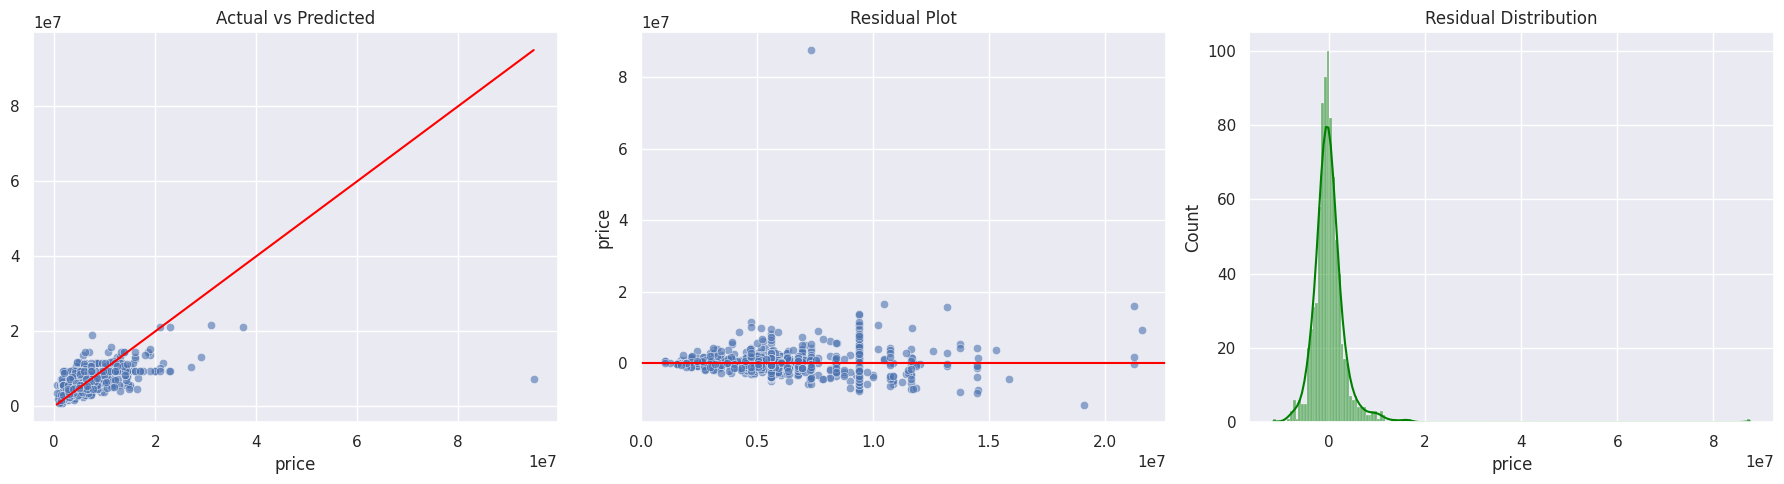

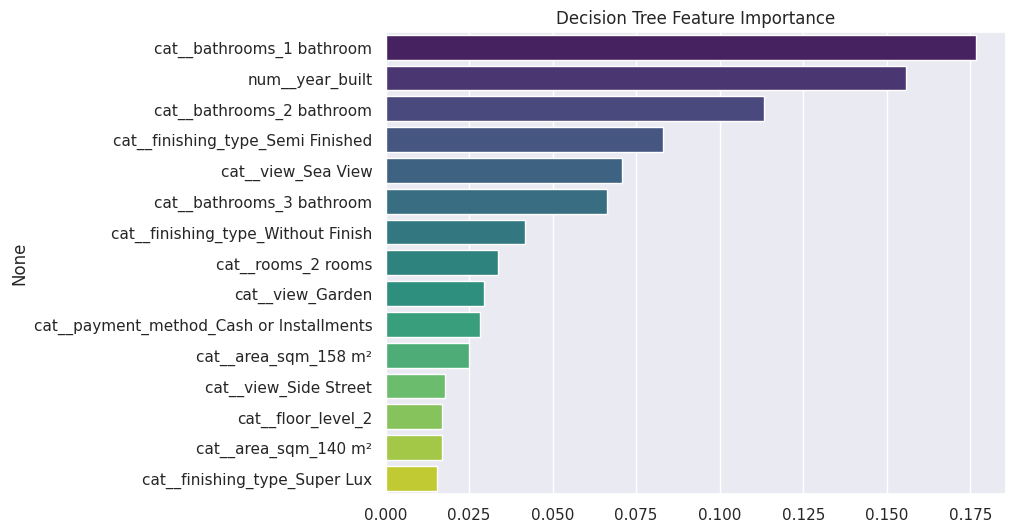

In [69]:
tree_model = train_model(

    DecisionTreeRegressor(

        random_state=42,

        max_depth=10,

        min_samples_leaf=5

    ),

    "Decision Tree"

)

Random Forest
MAE  : 1,910,189.00
RMSE : 4,288,407.28
R2   : 0.3103
AdjR2: 0.3026
MAPE : 0.3378


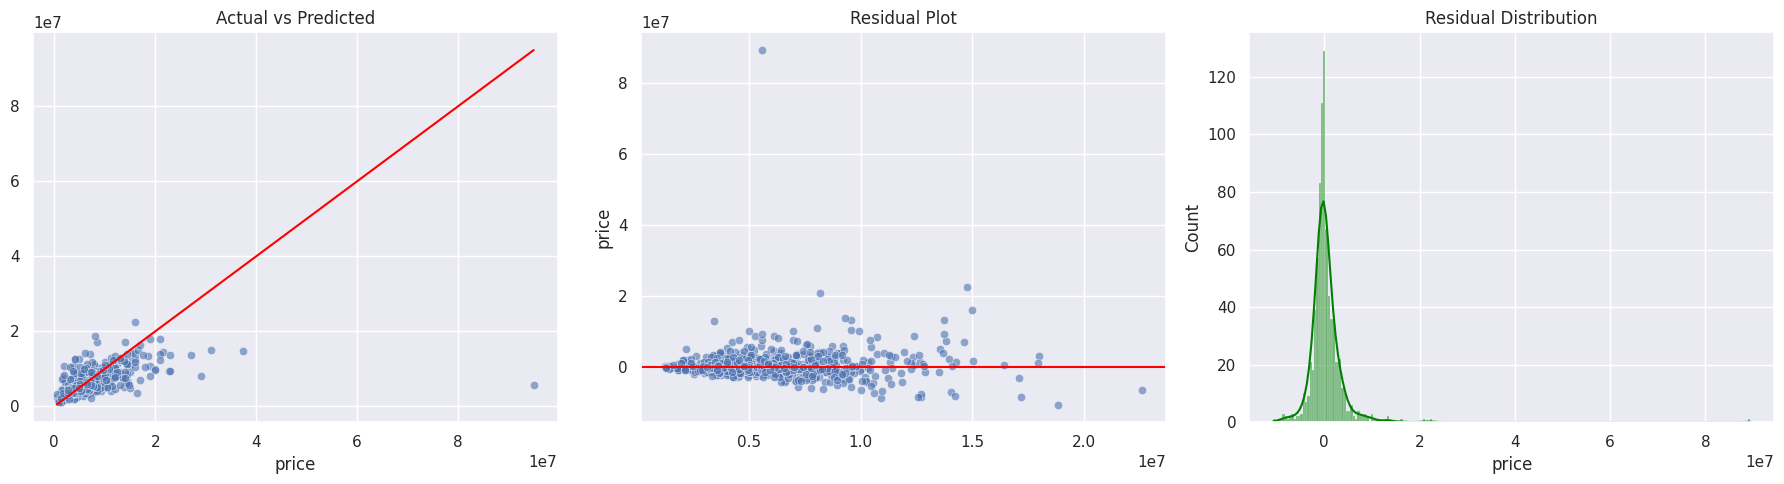

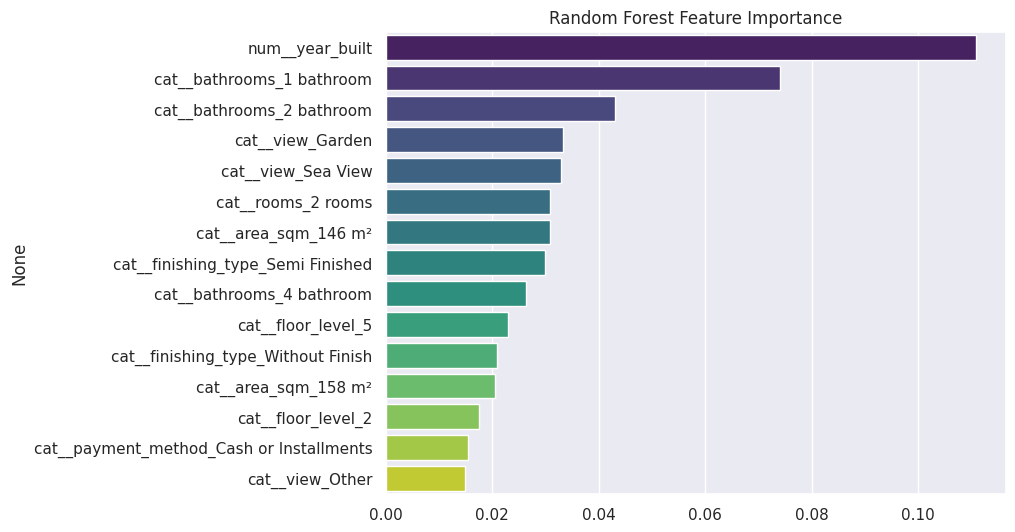

In [70]:
rf_model = train_model(

    RandomForestRegressor(

        n_estimators=300,

        random_state=42,

        n_jobs=-1

    ),

    "Random Forest"

)

Gradient Boosting
MAE  : 2,321,037.34
RMSE : 4,461,615.74
R2   : 0.2535
AdjR2: 0.2451
MAPE : 0.4715


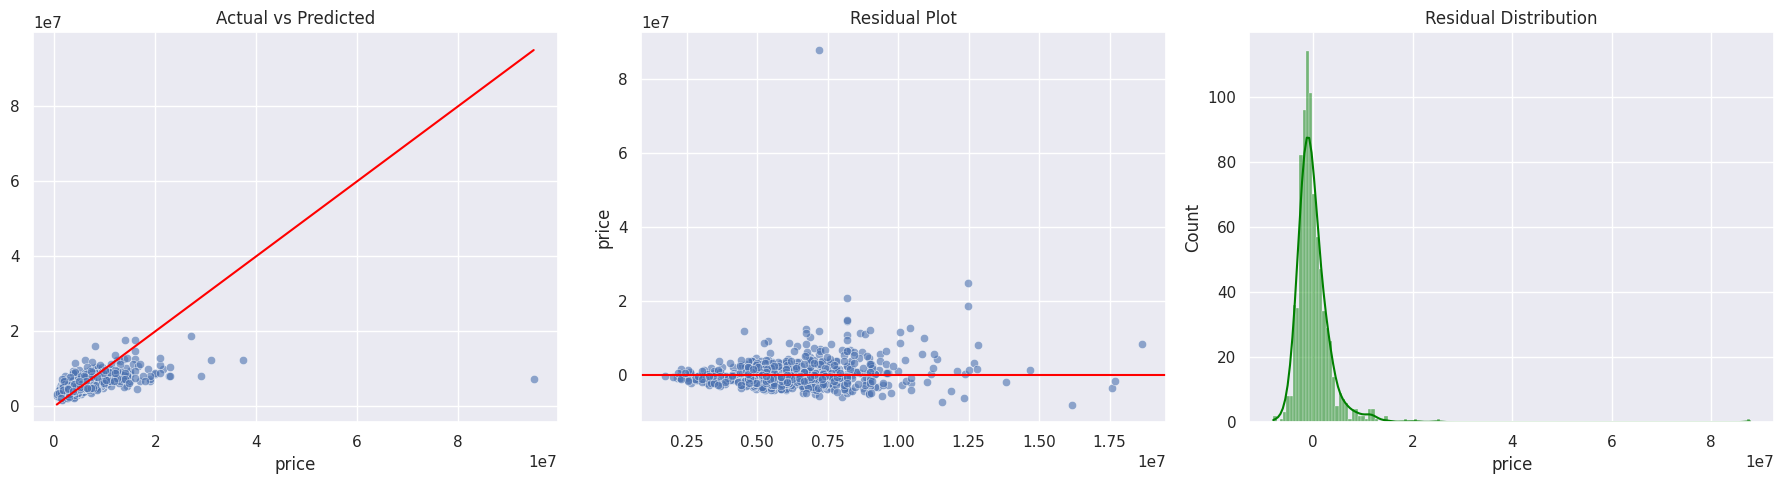

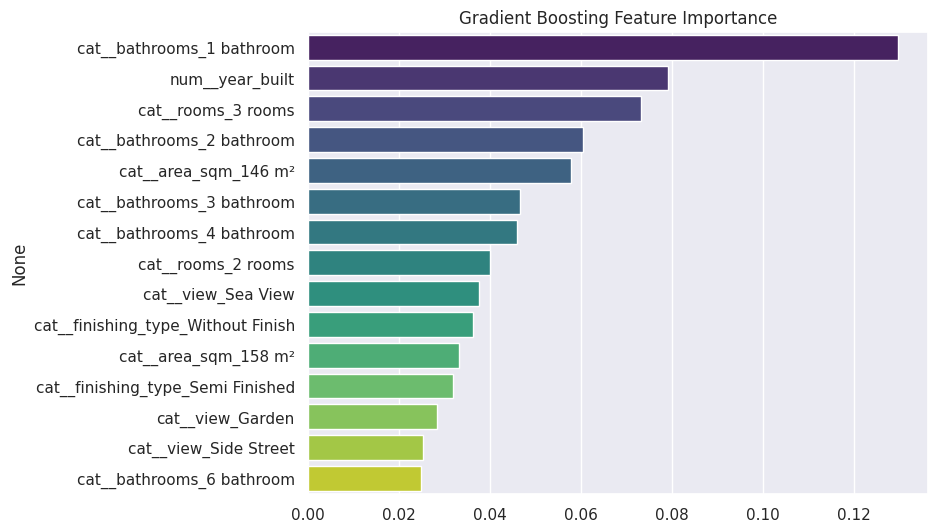

In [71]:
gb_model = train_model(

    GradientBoostingRegressor(

        random_state=42

    ),

    "Gradient Boosting"

)

SVR
MAE  : 2,939,508.35
RMSE : 5,346,856.94
R2   : -0.0722
AdjR2: -0.0841
MAPE : 0.5514


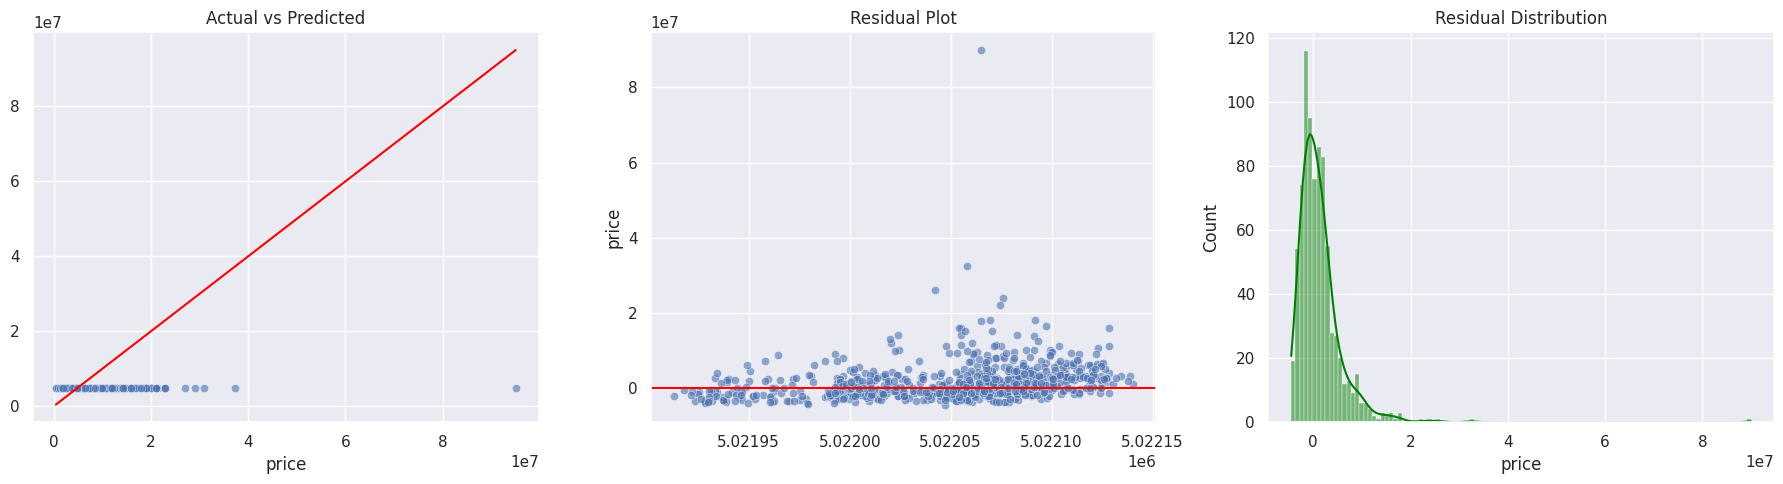

In [72]:
svr_model = train_model(

    SVR(),

    "SVR"

)

In [73]:
results_df = pd.DataFrame(results)

results_df.sort_values(

    "R2",

    ascending=False

)

,Model,MAE,RMSE,R2,Adj R2,MAPE
6,Random Forest,1.910189e+06,4.288407e+06,0.310299,0.302617,0.337769
5,Decision Tree,2.187527e+06,4.321321e+06,0.299671,0.291871,0.432134
1,Ridge Regression,2.270691e+06,4.449046e+06,0.257660,0.249392,0.451296
7,Gradient Boosting,2.321037e+06,4.461616e+06,0.253460,0.245145,0.471532
4,KNN Regressor,2.144471e+06,4.507566e+06,0.238003,0.229516,0.394404
2,Lasso Regression,2.293162e+06,4.575790e+06,0.214763,0.206016,0.433370
0,Linear Regression,2.293342e+06,4.576097e+06,0.214657,0.205910,0.433371
3,Elastic Net,2.775966e+06,4.958584e+06,0.077887,0.067616,0.616314
8,SVR,2.939508e+06,5.346857e+06,-0.072176,-0.084118,0.551405


In [74]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

param_dist = {

    "model__n_estimators":[100,200,300,500],

    "model__max_depth":[None,10,20,30,40],

    "model__min_samples_split":[2,5,10],

    "model__min_samples_leaf":[1,2,4],

    "model__max_features":["sqrt","log2"]

}

random_search = RandomizedSearchCV(

    estimator=pipe,

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train,y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}
0.37374201402022483


In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "model__n_estimators":[200,300,400],

    "model__max_depth":[20,30,None],

    "model__min_samples_leaf":[1,2],

    "model__min_samples_split":[2,5]

}

grid = GridSearchCV(

    estimator=random_search.best_estimator_,

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

print(grid.best_score_)

{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
0.3810408987535256


In [79]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2 = r2_score(y_test,y_pred)

mape = mean_absolute_percentage_error(y_test,y_pred)

print(f"MAE : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R² : {r2:.4f}")
print(f"MAPE : {mape:.4f}")

MAE : 1,973,106.24
RMSE : 4,308,622.36
R² : 0.3038
MAPE : 0.3845


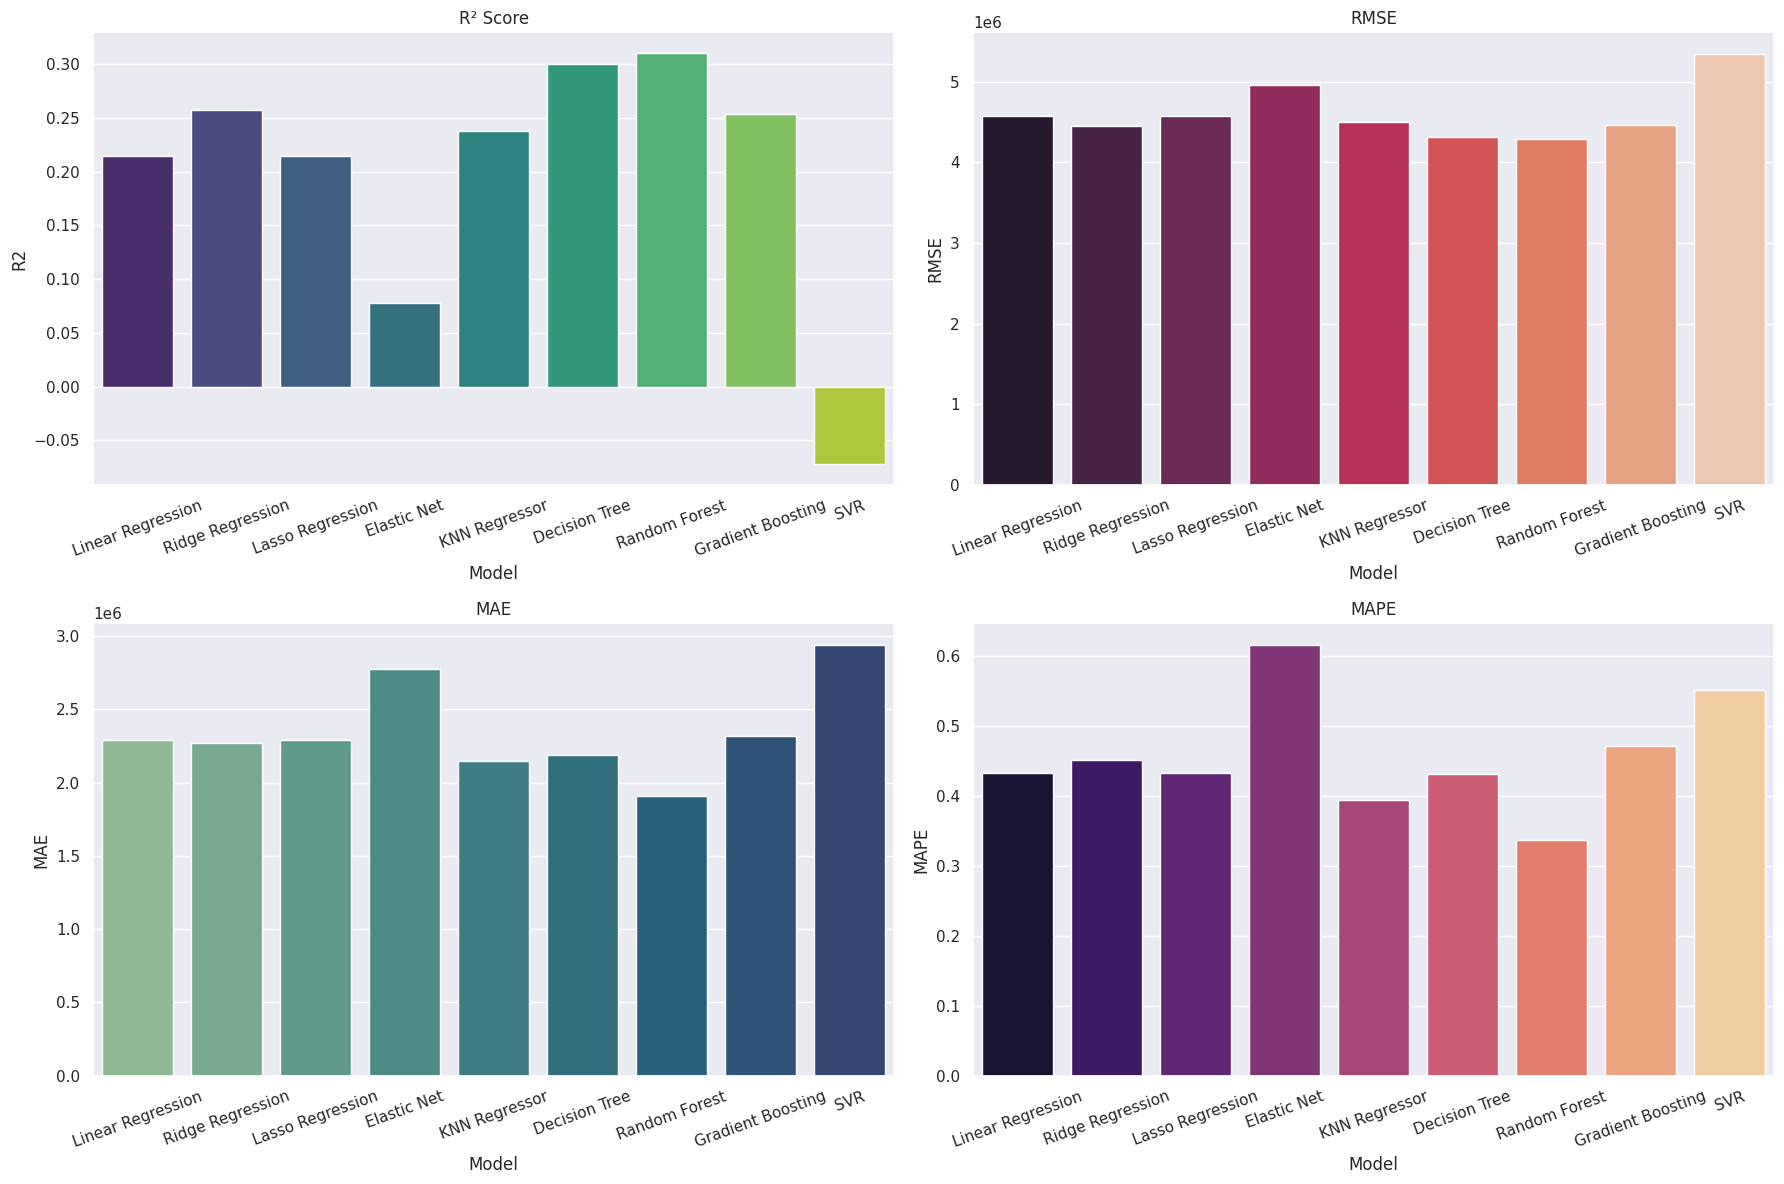

In [80]:
fig,ax=plt.subplots(2,2,figsize=(18,12))

sns.barplot(data=results_df,x="Model",y="R2",palette="viridis",ax=ax[0,0])
ax[0,0].set_title("R² Score")

sns.barplot(data=results_df,x="Model",y="RMSE",palette="rocket",ax=ax[0,1])
ax[0,1].set_title("RMSE")

sns.barplot(data=results_df,x="Model",y="MAE",palette="crest",ax=ax[1,0])
ax[1,0].set_title("MAE")

sns.barplot(data=results_df,x="Model",y="MAPE",palette="magma",ax=ax[1,1])
ax[1,1].set_title("MAPE")

for a in ax.flat:
    a.tick_params(axis='x',rotation=20)

plt.tight_layout()

plt.show()

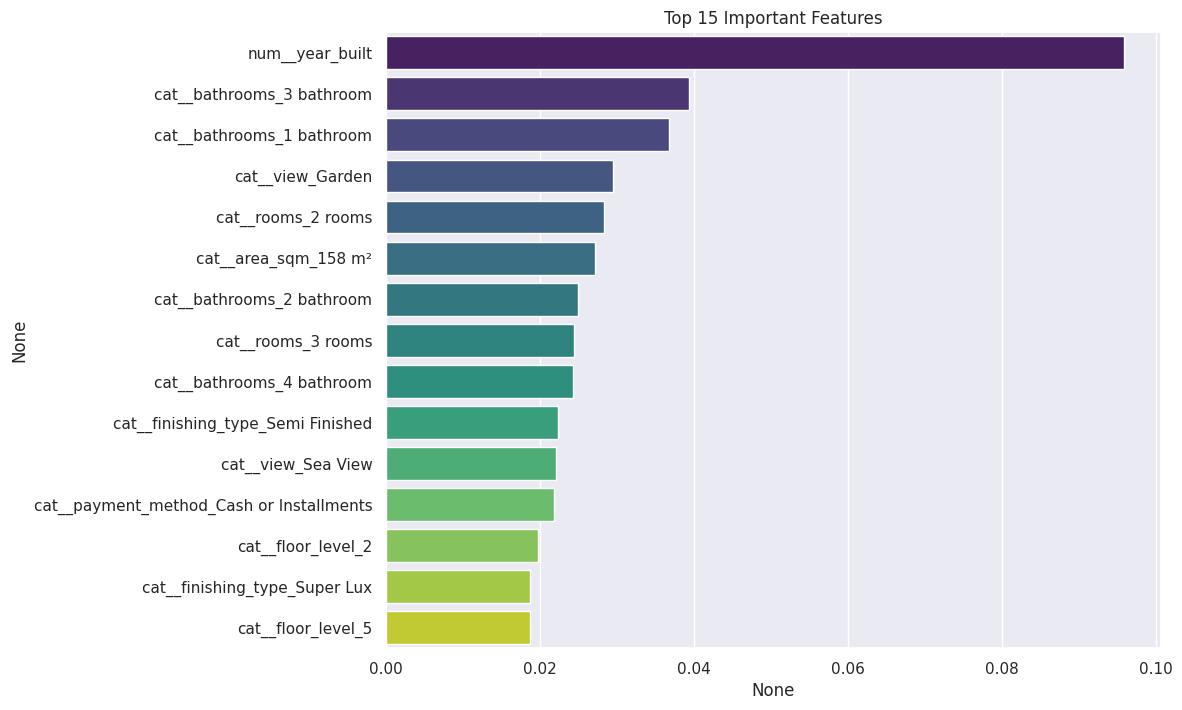

['num__year_built', 'cat__bathrooms_3 bathroom', 'cat__bathrooms_1 bathroom', 'cat__view_Garden', 'cat__rooms_2 rooms', 'cat__area_sqm_158 m²', 'cat__bathrooms_2 bathroom', 'cat__rooms_3 rooms']


In [81]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance = best_model.named_steps["model"].feature_importances_

importance = pd.Series(

    importance,

    index=feature_names

).sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(

    x=importance.head(15),

    y=importance.head(15).index,

    palette="viridis"

)

plt.title("Top 15 Important Features")

plt.show()

top_features = importance.head(8).index.tolist()

print(top_features)

In [82]:
# Top encoded features
top_features = importance.head(15).index.tolist()

important_inputs = []

for feat in top_features:

    # Numerical Features
    if feat.startswith("num__"):

        col = feat.replace("num__", "")

    # Categorical Features
    elif feat.startswith("cat__"):

        col = feat.replace("cat__", "").split("_", 1)[0]

    else:

        col = feat

    if col not in important_inputs:

        important_inputs.append(col)

print(important_inputs)

['year_built', 'bathrooms', 'view', 'rooms', 'area', 'finishing', 'payment', 'floor']


In [83]:
import gradio as gr
import pandas as pd

def predict_price(*values):

    sample = {}

    for col, value in zip(important_inputs, values):

        sample[col] = [value]

    sample = pd.DataFrame(sample)

    # الأعمدة اللى مش موجودة يضيفها
    for col in X.columns:

        if col not in sample.columns:

            if X[col].dtype == "object":

                sample[col] = df[col].mode()[0]

            else:

                sample[col] = df[col].median()

    sample = sample[X.columns]

    pred = best_model.predict(sample)[0]

    return f"Predicted Price : {pred:,.0f} EGP"

In [85]:
important_inputs = []

for feat in top_features:

    # Remove prefixes
    feat = feat.replace("num__", "").replace("cat__", "")

    # ابحث عن اسم العمود الأصلى
    original = None

    for col in X.columns:

        if feat.startswith(col):
            original = col
            break

    if original is not None and original not in important_inputs:
        important_inputs.append(original)

print(important_inputs)

['year_built', 'bathrooms', 'view', 'rooms', 'area_sqm', 'finishing_type', 'payment_method', 'floor_level']


In [86]:
demo = gr.Interface(

    fn=predict_price,

    inputs=inputs,

    outputs=gr.Textbox(label="Predicted Price"),

    title="🏠 Apartment Price Prediction",

    description="Predict apartment price using the most important features."

)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://21c266b4acfa26bbfb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
